[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muhammad-zainal-muttaqin/NulisBuku/blob/main/website/notebooks/ch02.ipynb)

Notebook Bab 2 ini punya dua bagian. Bagian **Demo** tinggal Anda jalankan lalu amati keluarannya; bagian **Mini Project** berisi soal dan data yang Anda kerjakan sendiri.

Intinya satu: parameter transformasi hanya boleh dipelajari dari data latih. Bila aturan itu dilanggar, muncul *data leakage* dan metrik evaluasi menjadi terlalu optimistis.

## Persiapan

Jalankan sel impor di bawah. Di Google Colab seluruh pustaka ini sudah tersedia; di laptop, pasang dulu lewat `pip install -r requirements.txt`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
print('Setup selesai.')

Setup selesai.


# Section 1 - Demo: *Pipeline* yang Valid vs. *Pipeline* yang Bocor

Kita menirukan skenario penaksir harga *real estate*. Atribut `luas_lahan` punya sebagian nilai yang hilang, lalu diisi dengan rata-rata (imputasi). Pertanyaan kuncinya: rata-rata itu dihitung sebelum atau sesudah data dipisah? Urutan itu yang menentukan evaluasi valid atau bocor.

## Data sintetis (harga *real estate*)

Harga dibangun sebagai fungsi linear dari beberapa fitur ditambah *noise*, lalu sebagian nilai `luas_lahan` sengaja dikosongkan.

In [2]:
n = 1200
luas_bangunan = rng.normal(120, 35, n).clip(30, None)
luas_lahan = rng.normal(180, 60, n).clip(40, None)
kamar = rng.integers(1, 6, n)
umur = rng.integers(0, 40, n)

harga = (350 * luas_bangunan + 220 * luas_lahan + 15000 * kamar
         - 1200 * umur + rng.normal(0, 20000, n))

X = pd.DataFrame({
    'luas_bangunan': luas_bangunan,
    'luas_lahan': luas_lahan,
    'kamar': kamar,
    'umur': umur,
})
y = pd.Series(harga, name='harga')

# Kosongkan sekitar 20 persen nilai luas_lahan.
mask = rng.random(n) < 0.20
X.loc[mask, 'luas_lahan'] = np.nan

print('Ukuran data:', X.shape)
print('Nilai hilang per kolom:')
print(X.isna().sum())
X.head()

Ukuran data: (1200, 4)
Nilai hilang per kolom:
luas_bangunan      0
luas_lahan       261
kamar              0
umur               0
dtype: int64


,luas_bangunan,luas_lahan,kamar,umur
0,130.665098,100.647532,2,8
1,83.600556,150.828352,4,35
2,146.265792,NaN,4,19
3,152.919765,173.856198,4,3
4,51.713768,140.966183,1,32


## Demo 1: imputasi/*scaling* global (bocor) vs *pipeline* (valid)

Pendekatan **(A) bocor** menghitung rata-rata dan skala dari *seluruh* data sebelum *split*, sehingga parameter ikut menyerap informasi data uji. Pendekatan **(B) valid** memisah data lebih dulu, lalu *pipeline* mem-*fit* parameter hanya pada data latih.

In [3]:
# (A) BOCOR: fit imputer & scaler pada SELURUH data, baru split.
X_all = StandardScaler().fit_transform(SimpleImputer(strategy='mean').fit_transform(X))
Xtr, Xte, ytr, yte = train_test_split(X_all, y, test_size=0.25, random_state=RANDOM_STATE)
m = Ridge(alpha=1.0, random_state=RANDOM_STATE).fit(Xtr, ytr)
r2_bocor = r2_score(yte, m.predict(Xte))

# (B) VALID: split dulu, pipeline fit hanya pada data latih.
Xtr2, Xte2, ytr2, yte2 = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE)
pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0, random_state=RANDOM_STATE)),
])
pipe.fit(Xtr2, ytr2)
r2_valid = r2_score(yte2, pipe.predict(Xte2))

print(f'(A) BOCOR  R2 uji = {r2_bocor:.4f}')
print(f'(B) VALID  R2 uji = {r2_valid:.4f}')

(A) BOCOR  R2 uji = 0.6748
(B) VALID  R2 uji = 0.6749


> 🔎 **Amati (Demo 1).** Pada satu kali *split*, selisih (A) dan (B) nyaris nol (lihat angka di atas) karena data uji tetap disisihkan saat prediksi. Kebocoran dari imputasi dan *scaling* memang sangat halus di skenario ini. Bahaya sesungguhnya muncul ketika evaluasi memakai *cross-validation* dan ketika langkah transformasinya banyak belajar dari data, persis seperti seleksi fitur pada Demo 2.

## Demo 2: seleksi fitur sebelum *split* menghasilkan metrik palsu

Inilah bentuk *leakage* yang paling sering tidak disadari. Kita pakai data yang **sepenuhnya acak**, jadi tidak ada hubungan nyata antara fitur dan target. Jika seleksi fitur mengintip seluruh data sebelum validasi, beberapa fitur *noise* akan tampak prediktif hanya karena kebetulan, lalu skor melambung secara semu.

In [4]:
from sklearn.feature_selection import SelectKBest, f_regression

# Data SEPENUHNYA acak: tidak ada sinyal sebenarnya.
Xn = rng.normal(size=(150, 500))
yn = rng.normal(size=150)
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# SALAH: pilih 10 fitur 'terbaik' memakai SELURUH data sebelum cross-validation.
Xn_sel = SelectKBest(f_regression, k=10).fit_transform(Xn, yn)
skor_bocor = cross_val_score(Ridge(alpha=1.0), Xn_sel, yn, cv=cv, scoring='r2')

# BENAR: seleksi berada di dalam pipeline, di-fit ulang pada tiap fold latih.
pipe_sel = Pipeline([
    ('select', SelectKBest(f_regression, k=10)),
    ('model', Ridge(alpha=1.0)),
])
skor_valid = cross_val_score(pipe_sel, Xn, yn, cv=cv, scoring='r2')

print(f'[BOCOR] R2 CV = {skor_bocor.mean():.4f}  (pada data yang sepenuhnya acak!)')
print(f'[VALID] R2 CV = {skor_valid.mean():.4f}')

[BOCOR] R2 CV = 0.1241  (pada data yang sepenuhnya acak!)
[VALID] R2 CV = -0.5448


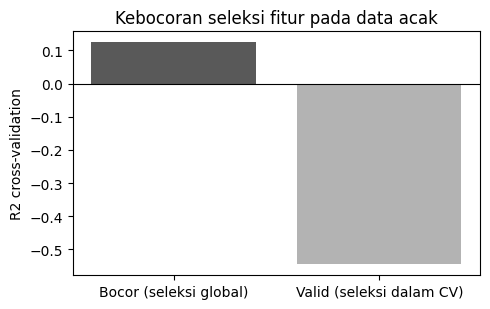

In [5]:
fig, ax = plt.subplots(figsize=(5, 3.2))
ax.bar(['Bocor (seleksi global)', 'Valid (seleksi dalam CV)'],
       [skor_bocor.mean(), skor_valid.mean()], color=['0.35', '0.7'])
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('R2 cross-validation')
ax.set_title('Kebocoran seleksi fitur pada data acak')
plt.tight_layout()
plt.show()

> 🔎 **Amati (Demo 2).** Skor (BOCOR) bisa terlihat positif padahal datanya murni acak: model seolah-olah belajar, padahal hanya menghafal kebetulan yang bocor dari data uji. Skor (VALID) berada di sekitar nol atau negatif, sesuai kenyataan bahwa datanya tanpa sinyal. Pelajarannya: seluruh langkah yang *belajar* dari data (imputasi, *scaling*, seleksi fitur) wajib berada di dalam *pipeline* agar di-*fit* ulang pada tiap *fold*.

# Section 2 - Mini Project

## Soal

Anda menerima data riwayat kunjungan pelanggan sebuah klinik. Tiap pelanggan (`id_pelanggan`) bisa memiliki beberapa baris kunjungan pada tanggal berbeda. Tujuannya memprediksi `tagihan`.

Bangun evaluasi yang bebas *leakage*:

1. Pilih strategi *split* yang tepat (perhatikan struktur kelompok pada `id_pelanggan`).
2. Susun *pipeline* (imputasi + *scaling* + encoding kategorikal + model) yang mem-*fit* parameter hanya pada data latih.
3. Laporkan estimasi performa dengan *cross-validation* yang sesuai.

**Luaran:** satu sel kode berisi *pipeline* dan skema validasi, ditambah 2-3 kalimat alasan mengapa strategi *split* pilihan Anda mencegah *leakage*.

**Kriteria penilaian:** (a) tidak ada *fit* pada data uji; (b) baris dengan `id_pelanggan` yang sama tidak tersebar ke latih dan uji sekaligus; (c) metrik dilaporkan dari data yang tidak tersentuh saat pelatihan.

In [6]:
# DATA AWAL (jangan diubah) - riwayat kunjungan klinik dengan struktur kelompok per pelanggan.
n_baris = 600
id_unik = np.arange(1000, 1200)                      # 200 pelanggan
id_pelanggan = rng.choice(id_unik, size=n_baris)     # beberapa kunjungan per pelanggan
efek_pelanggan = dict(zip(id_unik, rng.normal(0, 400000, id_unik.size)))

df = pd.DataFrame({
    'id_pelanggan': id_pelanggan,
    'usia': rng.integers(18, 80, n_baris),
    'lama_kunjungan_menit': rng.normal(35, 12, n_baris).clip(5, None),
    'jenis_layanan': rng.choice(['umum', 'spesialis', 'darurat'], n_baris),
})
peta_jenis = {'umum': 0, 'spesialis': 600000, 'darurat': 1200000}
df['tagihan'] = (50000 + 1500 * df['usia'] + 8000 * df['lama_kunjungan_menit']
                 + df['jenis_layanan'].map(peta_jenis)
                 + df['id_pelanggan'].map(efek_pelanggan)
                 + rng.normal(0, 80000, n_baris))
df.loc[rng.random(n_baris) < 0.10, 'lama_kunjungan_menit'] = np.nan

print('Data awal:', df.shape, '| pelanggan unik:', df['id_pelanggan'].nunique())
df.head()

Data awal: (600, 5) | pelanggan unik: 187


,id_pelanggan,usia,lama_kunjungan_menit,jenis_layanan,tagihan
0,1144,32,33.800753,darurat,1.411539e+06
1,1019,57,47.413254,umum,1.854435e+05
2,1036,31,23.361600,spesialis,1.278066e+06
3,1078,33,NaN,umum,8.766586e+04
4,1172,75,42.017334,umum,1.498086e+05


In [7]:
# Kerjakan di sini.
# Petunjuk: lihat sklearn.model_selection.GroupKFold dan sklearn.compose.ColumnTransformer.
